In [1]:
# colocate mode velocity reward training debug notebook

# 1. load model & dataset
# 2. initialize PerTokenAdvantageTrainer (vllm colocate mode )
# 3. train with log. 
# Issues: (1) no reward logging for correct rollout 

In [1]:
# ── 1. Setup ────────────────────────────────────────────────────────────────
# Run from repo root. Keeps everything in a scratch dir so we can rm -rf safely.
import os, sys, json, shutil, random
from pathlib import Path

REPO = Path(".")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

OUT = REPO / "output" / "debug_vrl"
if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)
print("scratch dir:", OUT)

# Toggle: vLLM colocate is what the bug was observed under, but the velocity-
# log code path is identical with use_vllm=False (HF generate). Flip to True
# on a CUDA box to reproduce in the exact training config.
USE_VLLM   = False
MODEL_NAME = "Qwen/Qwen3-0.6B"
N_STEPS    = 3
N_GEN      = 4              # rollouts per prompt
PDB        = 2              # per_device_train_batch_size
GAS        = 2              # gradient_accumulation_steps
MAX_COMP   = 1024
SEED       = 0
random.seed(SEED)

import numpy as np, torch
np.random.seed(SEED); torch.manual_seed(SEED)
print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())


scratch dir: output/debug_vrl
torch: 2.9.1 cuda: False


In [2]:
# ── 2. Dataset (tiny) + model/tokenizer ─────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM
from src.game24utils import (
    build_puzzle_pool, bucket_by_difficulty, make_splits, build_datasets,
    correctness_reward, format_reward,
)

puzzles = build_puzzle_pool(max_n=9)
easy, medium, hard = bucket_by_difficulty(puzzles, easy_min=8, hard_max=2)
train_p, eval_p, hard_probe = make_splits(easy, medium, hard, eval_frac=0.10, probe_frac=0.40)
train_ds, eval_ds, _ = build_datasets(train_p, eval_p, hard_probe)

# Shrink to keep the debug fast — we only need a few prompts.
train_ds = train_ds.select(range(min(16, len(train_ds))))
print("train_ds rows:", len(train_ds))
print("sample row:", train_ds[0])

tok   = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16)
print("loaded:", MODEL_NAME)


train_ds rows: 16
sample row: {'prompt': [{'content': "You play the Game of 24. Given four numbers, you must write a single arithmetic expression using each number exactly once with + - * / and parentheses that evaluates to 24.\n\nThink step by step. First reason about how to combine the numbers, then on the final line output only the expression after '#### '.\nExample final line: '#### (3+5)*(7-4)'.", 'role': 'system'}, {'content': "Given numbers: 3,3,5,9. Make 24. Think step by step, then give your final expression on the last line after '#### '.", 'role': 'user'}], 'numbers': [3, 3, 5, 9], 'solutions': ['((3+5)/3)*9', '(3+5)/(3/9)', '((3+5)*9)/3', '(3+5)*(9/3)', '3*(5+(9/3))', '(9+3)*(5-3)', '(9*(3+5))/3', '9*((3+5)/3)', '((9/3)+5)*3', '(9/3)*(5+3)', '9/(3/(5+3))', '3*((9/3)+5)', '((5+3)*9)/3', '(5+3)*(9/3)', '(5-3)*(9+3)', '(5+(9/3))*3', '(3+3)*(9-5)', '(9/3)*(3+5)', '9/(3/(3+5))', '(9-5)*(3+3)', '(9*(5+3))/3', '9*((5+3)/3)', '((5+3)/3)*9', '(5+3)/(3/9)', '(5-3)*(3+9)', '(3+9)*(5-3

`torch_dtype` is deprecated! Use `dtype` instead!


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

loaded: Qwen/Qwen3-0.6B


In [3]:
# ── 3. Seed the answer buffer with dataset-provided solutions ───────────────
# Mirrors ablate_game24.py:319-325. Without seeding, buffer.sample returns
# empty for every query → the else-branch ref is empty → ALL rollouts get
# silently skipped at the gate. That would explain an empty velocity_log
# but NOT the observed pattern (0 correct out of 3200 logged), so we want a
# populated buffer to isolate the *correct-rollout* path.
from src.online_buffer import OnlineBuffer
from src.velocity import VelocityRewardComputer
from script.ablate_game24 import (
    game24_is_correct,
    game24_query_key,
    game24_task_extras,
)

answer_buffer = OnlineBuffer(capacity_per_query=64)
n_seed = 0
for row in train_ds:
    qk = tuple(row["numbers"])
    for expr in (row.get("solutions") or []):
        n_seed += int(answer_buffer.add(qk, expr))
print(f"buffer seeded: {n_seed} entries / {answer_buffer.num_queries()} queries")

vel_computer = VelocityRewardComputer(
    answer_buffer,
    chunk_strategy="uniform",
    chunk_size=16,
    normalize_by_chunk=True,
    penalty_on_truncated=True,    # rollouts without </think>#### get reward -10 on every real token
    penalty_on_incorrect=True,    # incorrect rollouts get reward -10 on every real token (skip velocity compute)
)


objc[24253]: Class AVFFrameReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2d8df0798) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x2eda583a8). One of the two will be used. Which one is undefined.
objc[24253]: Class AVFAudioReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2d8df07e8) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x2eda583f8). One of the two will be used. Which one is undefined.


buffer seeded: 412 entries / 16 queries


In [4]:
# ── 4. Build trainer ────────────────────────────────────────────────────────
from trl import GRPOConfig
from src.pertoken_trainer import PerTokenAdvantageTrainer

cfg = GRPOConfig(
    output_dir=str(OUT),
    num_generations=N_GEN,
    max_completion_length=MAX_COMP,
    per_device_train_batch_size=PDB,
    gradient_accumulation_steps=GAS,
    learning_rate=5e-6,
    max_steps=N_STEPS,
    logging_steps=1,
    bf16=True,
    save_strategy="no",
    report_to="none",
    use_vllm=USE_VLLM,
)

trainer = PerTokenAdvantageTrainer(
    model=model,
    reward_funcs=[correctness_reward, format_reward],
    args=cfg,
    train_dataset=train_ds,
    processing_class=tok,
    adv_mode="token", adv_n_chunks=8, adv_stride=5,
    velocity_computer=vel_computer,
    is_correct=game24_is_correct,
    query_key_fn=game24_query_key,
    task_extras_fn=game24_task_extras,
)
print("trainer ready; logs →")
print(" ", trainer._resolve_log_path(in_eval=False))
print(" ", trainer._resolve_log_path(in_eval=True))


[2026-05-27 11:33:11,522] [INFO] [real_accelerator.py:222:get_accelerator] Setting ds_accelerator to mps (auto detect)


W0527 11:33:11.635000 24253 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


trainer ready; logs →
  output/debug_vrl/rollouts.jsonl
  output/debug_vrl/eval_rollouts.jsonl


In [ ]:
# ── 6. Train a few steps ────────────────────────────────────────────────────
trainer.train()
print("done. files in", OUT, ":")
for p in sorted(OUT.iterdir()):
    print(f"  {p.name:30s}  {p.stat().st_size:>8d} bytes")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
1,0.000000


In [ ]:
# [Another line of ablation]
# - whether the "prefix buffer" & "answer buffer" help
# - based on GRPO algorithm, does it help to add prefix buffer? 
# - based on GRPO algorithm, does it help to "force in" the answer? 

In [7]:
# [Issue 1]. There is zero correct rollout, yet the loss is near zero.
# [Issue 2]. ALmost all rolllouts are truncated
# [Issue 3]. avg. velocity reward over token do NOT increase as training progresses
# [Issue 4]. loss is near zero for all steps

# [Sanity Check]. if we overwrite a high reward for generating "*" sign, can we get the model to overfit it? if yes, we know 
#                 we need to fix the "reward function", otherwise we know there is a bug with the connection logic, in which 
#                 case, it's worth adding a proper "reward function" instead of using the weird wrapper that ignores reward function
# [Idea 1]. Instead of log(p(a | o)) - log(p(a)) reward which can be positive / negative, we want a positive reward that allows
#           us to set zero reward (penalty) for truncated rollouts, we can use p(a | o) / p(a) for this, if sanity check works out
# [Issue 5]. bug with 'prob ratio' mode --- model generation method gives error
#            in 'log_ratio' mode, this bug do not exists

def load_jsonl(p):
    return [json.loads(l) for l in Path(p).read_text().splitlines() if l.strip()]

ro = load_jsonl("logs/debug_vrl/rollouts_v2.jsonl")
print(f"rollouts.jsonl       : {len(ro):4d}  correct={sum(r['correct'] for r in ro)}")

sample = ro[-1]
# sample
sample.keys()
global_idx = sample['global_step']
inner_idx = sample['inner_step']
idx = sample['idx']
completion_str = sample['completion']
n_tokens = sample['n_tokens']
r_t = sample['r_t'] # velocity reward per token
adv = sample['advantage'] # advantage per token
loss = sample['loss'] # loss per token
correct = sample['correct'] # correctness 
expr = sample['expr'] # answer in the response


rollouts.jsonl       :   80  correct=0


In [1]:
# Question 1. Does reward increase as training progresses? What is the model "overfitting on"?
#   Fig 1: avg r_t over all tokens & rollouts vs. step (static line plot).
#   Fig 2: avg r_t per token position vs. step (animated .gif, one frame per step).
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from collections import defaultdict
from IPython.display import Image, display

FIG_DIR = Path("logs/debug_vrl")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Group rollouts by (global_step, inner_step). Treat each (gs, inner) as one
# optimizer micro-step; sort to get a stable step axis.
groups = defaultdict(list)
for r in ro:
    groups[(r["global_step"], r["inner_step"])].append(r["r_t"])

step_keys = sorted(groups.keys())
step_idx  = list(range(len(step_keys)))

# ── Figure 1: mean r_t (over tokens & rollouts) per step ───────────────────
mean_per_step = [
    float(np.mean([t for rt in groups[k] for t in rt])) for k in step_keys
]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(step_idx, mean_per_step, marker="o", lw=1.5)
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("step (global_step, inner_step) index")
ax.set_ylabel("avg r_t (over tokens × rollouts)")
ax.set_title("Mean velocity reward per training step")
ax.set_xticks(step_idx)
ax.set_xticklabels([f"{gs},{i}" for gs, i in step_keys], rotation=0)
fig.tight_layout()
fig1_path = FIG_DIR / "rt_mean_per_step.png"
fig.savefig(fig1_path, dpi=120)
plt.show()
print("saved:", fig1_path)

# ── Figure 2: animated per-token r_t profile across steps ─────────────────
# Pad each rollout's r_t to the max length with NaN so we can nan-mean across
# rollouts of unequal length within the same step.
def pad_stack(lists, T):
    out = np.full((len(lists), T), np.nan, dtype=float)
    for i, l in enumerate(lists):
        out[i, : len(l)] = l
    return out

T_max  = max((len(rt) for rts in groups.values() for rt in rts), default=0)
frames = []
for k in step_keys:
    arr = pad_stack(groups[k], T_max)
    frames.append(np.nanmean(arr, axis=0))  # (T_max,)

ymin = float(np.nanmin(frames))
ymax = float(np.nanmax(frames))
pad  = 0.1 * (ymax - ymin + 1e-6)

fig, ax = plt.subplots(figsize=(8, 4))
(line,) = ax.plot([], [], lw=1.2)
ax.set_xlim(0, T_max - 1)
ax.set_ylim(ymin - pad, ymax + pad)
ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.set_xlabel("token position")
ax.set_ylabel("avg r_t over rollouts")
title = ax.set_title("")

def _update(i):
    y = frames[i]
    line.set_data(np.arange(T_max), y)
    gs, inner = step_keys[i]
    title.set_text(f"step (gs={gs}, inner={inner})  —  frame {i+1}/{len(frames)}")
    return line, title

anim = FuncAnimation(fig, _update, frames=len(frames), interval=600, blit=False)
gif_path = FIG_DIR / "rt_trajectory_evolution.gif"
anim.save(gif_path, writer=PillowWriter(fps=2))
plt.close(fig)
print("saved:", gif_path)
display(Image(filename=str(gif_path)))


NameError: name 'Path' is not defined

/var/folders/bt/rngwf7wj73x2zfr_7chtd0jh0000gn/T/ipykernel_52738/304445123.py:36: RuntimeWarning: Mean of empty slice
  frames = [np.nanmean(pad_stack(groups_loss[k], T_max), axis=0) for k in step_keys]
[2026-05-26 18:01:12] INFO animation.py:1060: Animation.save using <class 'matplotlib.animation.PillowWriter'>


saved: logs/debug_vrl/loss_evolution.gif


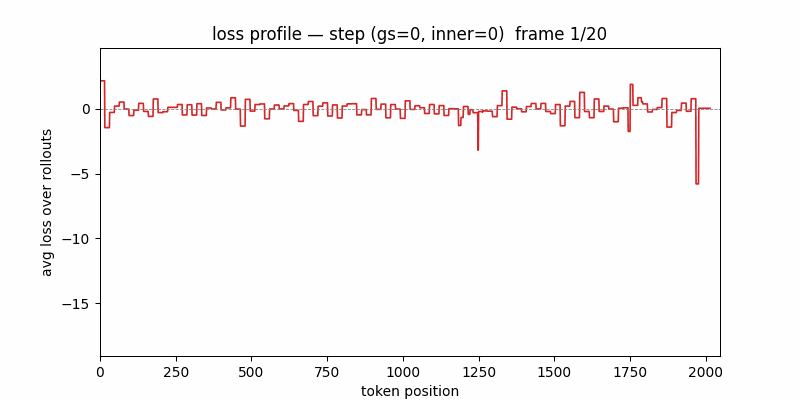

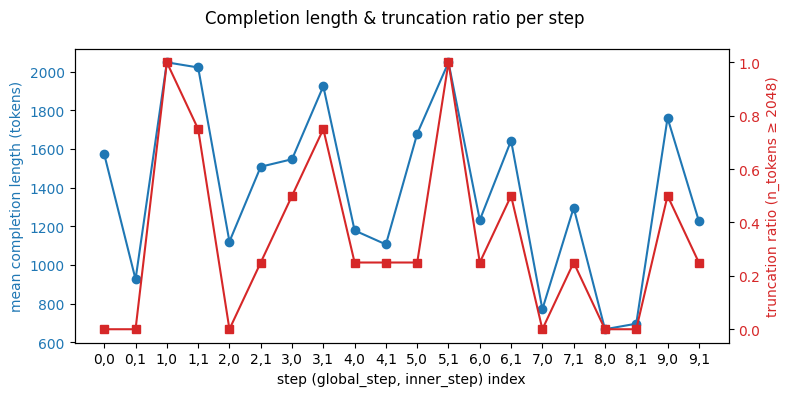

saved: logs/debug_vrl/length_truncation_per_step.png


In [9]:
# Question 2. How does avg loss evolve over training? → .gif of per-token loss profile per step.
# Question 3. How does length / truncation ratio evolve over training? → static plot.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from collections import defaultdict
from IPython.display import Image, display

FIG_DIR = Path("logs/debug_vrl")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Group by (global_step, inner_step). Re-use the same step axis as Q1.
groups_loss = defaultdict(list)
groups_len  = defaultdict(list)
for r in ro:
    key = (r["global_step"], r["inner_step"])
    groups_loss[key].append(r["loss"])
    groups_len[key].append(int(r["n_tokens"]))

step_keys = sorted(groups_loss.keys())
step_idx  = list(range(len(step_keys)))

# Treat rollouts whose length equals the global max observed length as truncated.
# (MAX_COMP from cell 1 is the configured cap; using observed max keeps this
# robust to reruns with different caps that share the same rollouts.jsonl.)
max_len_observed = max((n for ns in groups_len.values() for n in ns), default=0)

# ── Q2: animated per-token loss profile ───────────────────────────────────
def pad_stack(lists, T):
    out = np.full((len(lists), T), np.nan, dtype=float)
    for i, l in enumerate(lists):
        out[i, : len(l)] = l
    return out

T_max  = max((len(l) for ls in groups_loss.values() for l in ls), default=0)
frames = [np.nanmean(pad_stack(groups_loss[k], T_max), axis=0) for k in step_keys]

ymin = float(np.nanmin(frames))
ymax = float(np.nanmax(frames))
pad  = 0.1 * (ymax - ymin + 1e-6)

fig, ax = plt.subplots(figsize=(8, 4))
(line,) = ax.plot([], [], lw=1.2, color="C3")
ax.set_xlim(0, T_max - 1)
ax.set_ylim(ymin - pad, ymax + pad)
ax.axhline(0, color="grey", lw=0.6, ls="--")
ax.set_xlabel("token position")
ax.set_ylabel("avg loss over rollouts")
title = ax.set_title("")

def _update(i):
    line.set_data(np.arange(T_max), frames[i])
    gs, inner = step_keys[i]
    title.set_text(f"loss profile — step (gs={gs}, inner={inner})  frame {i+1}/{len(frames)}")
    return line, title

anim = FuncAnimation(fig, _update, frames=len(frames), interval=600, blit=False)
loss_gif = FIG_DIR / "loss_evolution.gif"
anim.save(loss_gif, writer=PillowWriter(fps=2))
plt.close(fig)
print("saved:", loss_gif)
display(Image(filename=str(loss_gif)))

# ── Q3: mean length + truncation ratio per step ───────────────────────────
mean_len   = [float(np.mean(groups_len[k]))                              for k in step_keys]
trunc_frac = [float(np.mean([n >= max_len_observed for n in groups_len[k]])) for k in step_keys]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(step_idx, mean_len, marker="o", color="C0", label="mean length")
ax1.set_xlabel("step (global_step, inner_step) index")
ax1.set_ylabel("mean completion length (tokens)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.set_xticks(step_idx)
ax1.set_xticklabels([f"{gs},{i}" for gs, i in step_keys])

ax2 = ax1.twinx()
ax2.plot(step_idx, trunc_frac, marker="s", color="C3", label="truncation ratio")
ax2.set_ylabel(f"truncation ratio (n_tokens ≥ {max_len_observed})", color="C3")
ax2.set_ylim(-0.05, 1.05)
ax2.tick_params(axis="y", labelcolor="C3")

fig.suptitle("Completion length & truncation ratio per step")
fig.tight_layout()
len_path = FIG_DIR / "length_truncation_per_step.png"
fig.savefig(len_path, dpi=120)
plt.show()
print("saved:", len_path)
